In [1]:
import tensorflow as tf 

gpus = tf.config.list_physical_devices("GPU")

print(gpus)

2025-01-18 17:00:09.120416: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-18 17:00:09.147992: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-18 17:00:09.148011: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-18 17:00:09.148861: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-18 17:00:09.153673: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import sys
sys.path.append('../tools_')

from tools import *

In [3]:
data_short_dir = "/home/alumnos/mburgosc/tfg/egm_reconstruction/Data_short"
egms_all_models = load_egms_df(data_short_dir)

data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']


In [4]:
print(egms_all_models)

                              id  \
0   Simulation_01_210209_001_002   
1             LA_RSPV_CAF_150115   
2   Simulation_01_200428_001_001   
3   Simulation_01_201223_001_002   
4   Simulation_01_190619_001_004   
5   Simulation_01_190502_001_004   
6                 RA_RAFW_140807   
7                  RA_RAA_141230   
8   Simulation_01_200316_001_  1   
9               TwoRotors_181219   
10            RA_RAFW_SAF_140730   
11  Simulation_01_200212_001_  4   

                                            AF_signal  
0   [[9.479828179102282e-14, 0.04080228461795585, ...  
1   [[7.387776530722087, 9.094867906767199, 10.800...  
2   [[0.8807414426522221, 1.015404814148348, 0.963...  
3   [[4.24492593645743, 4.6424979299912765, 5.0315...  
4   [[-50.648764509652416, -48.25332554580271, -44...  
5   [[-61.093924858397685, -56.059614688222744, -5...  
6   [[-15.990956008585043, -14.190372868776846, -1...  
7   [[-1.5399639907851848, -1.421404688195314, -1....  
8   [[2.593443248791235, 2.

In [25]:
egms_values = egms_all_models["AF_signal"].tolist()
print(egms_values[0].shape)
print(len(egms_values))

(2048, 1500)
12


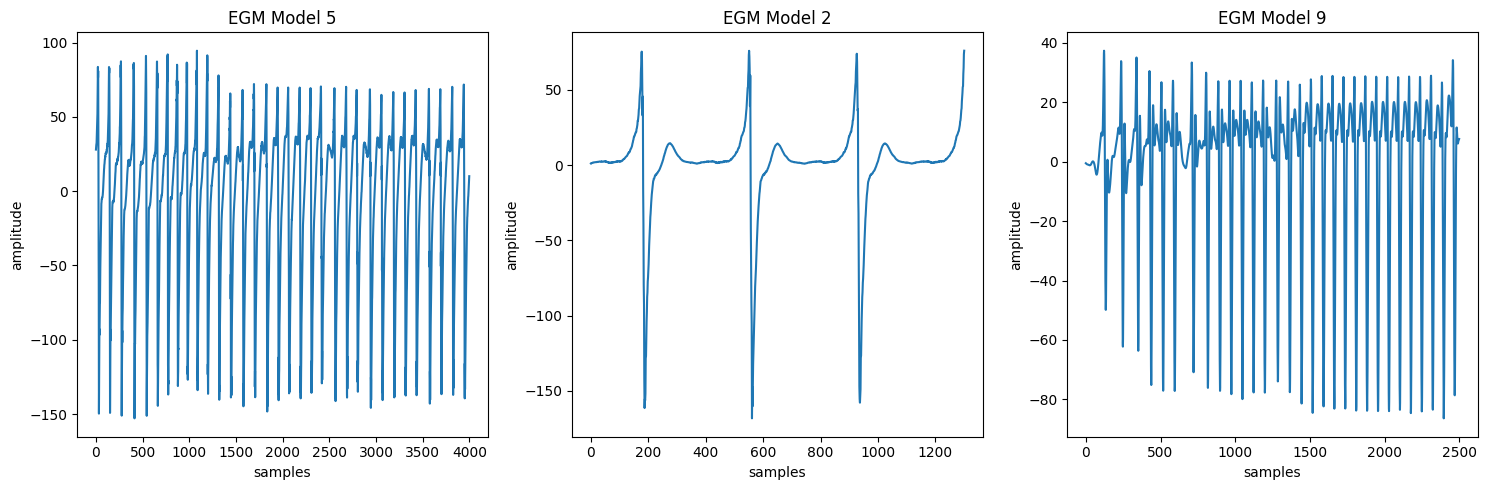

In [84]:
#plotting egms

import random

random_indices = random.sample(range(len(egms_values)), 3)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(random_indices):
    axs[i].plot(egms_values[idx][10, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()


In [28]:

egms_filtered_norm = []

for i in range(len(egms_values)):
    
    #ECG FILTERING
    egms = egms_values[i]
    egms_filt = ECG_filtering(egms, 500)


    #NORMLIZE EGMS
    high = 1
    low = -1

    mins = np.min(egms_filt, axis=0)
    maxs = np.max(egms_filt, axis=0)
    rng = maxs - mins

    norm_egms = high - (((high - low) * (maxs - egms_filt)) / rng)
    
    egms_filtered_norm.append(norm_egms)



In [31]:
print(len(egms_filtered_norm))
print(egms_filtered_norm[0].shape)

12
(2048, 1500)


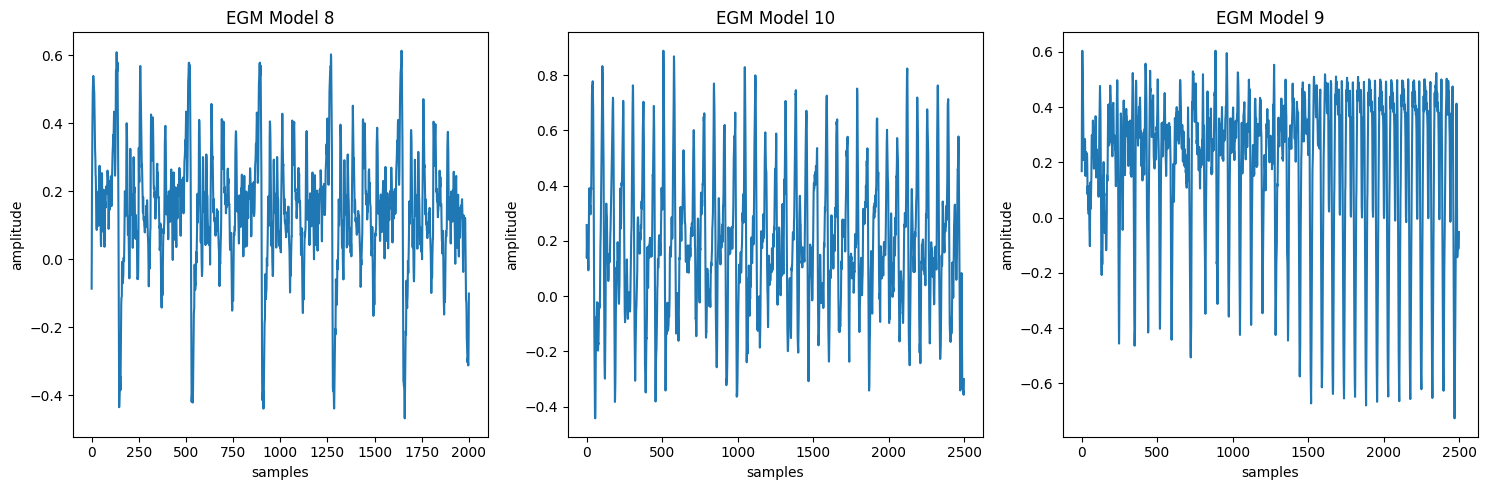

In [83]:
#plotting egms filtered and normalized

random_ind = random.sample(range(len(egms_filtered_norm)), 3)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(random_ind):
    axs[i].plot(egms_filtered_norm[idx][10, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()

In [47]:
transfer_matrices = load_transfer(ten_leads=False, bsps_set=False)

2


In [59]:
print(transfer_matrices[0][1].shape) #--> 64 electrodes 
print(transfer_matrices[0][0].shape)
print(transfer_matrices[1][0].shape)
print(transfer_matrices[1][1].shape) 

(64, 1)
(3610, 2048)
(3970, 2048)
(64, 1)


In [34]:
#COMPUTING THE FORWARD PROBLEM

A = transfer_matrices[0]

print(A)
print(A[1].shape) #--> matriz de transferencia

bsps_all_models = []
for i in range(len(egms_filtered_norm)):

    y_f = forward_problem(egms_filtered_norm[i], A[0]) # bsps
    bsps_all_models.append(y_f)


(array([[ 7.69965054e-05,  7.34290114e-05,  5.55983500e-05, ...,
        -4.30014225e-04,  3.20904568e-03,  2.03465098e-03],
       [-1.46424028e-04, -1.47995566e-04, -6.64696334e-05, ...,
         6.82507351e-04, -1.64109737e-03, -7.97225589e-04],
       [-1.17874811e-04, -1.11635205e-04, -5.44792074e-05, ...,
        -2.10877594e-04, -1.42770170e-03, -1.17830147e-03],
       ...,
       [-4.31684863e-05, -3.11358531e-05, -1.69536380e-05, ...,
        -1.81270509e-04, -4.25855593e-05, -2.64389011e-04],
       [-9.15845321e-05, -8.35069368e-05, -4.04402041e-05, ...,
        -4.26394139e-04, -9.76937571e-04, -9.75087733e-04],
       [-5.75701441e-05, -4.84485410e-05, -3.20869635e-05, ...,
         2.06745799e-04, -1.04379968e-03, -9.80077168e-04]]), array([[ 552],
       [3422],
       [2994],
       [  46],
       [ 971],
       [2982],
       [ 520],
       [ 522],
       [3502],
       [3188],
       [ 674],
       [ 472],
       [2694],
       [2641],
       [  18],
       [  40],
 

In [45]:
print(bsps_all_models[1].shape)

(3610, 2499)


(3610, 1500)


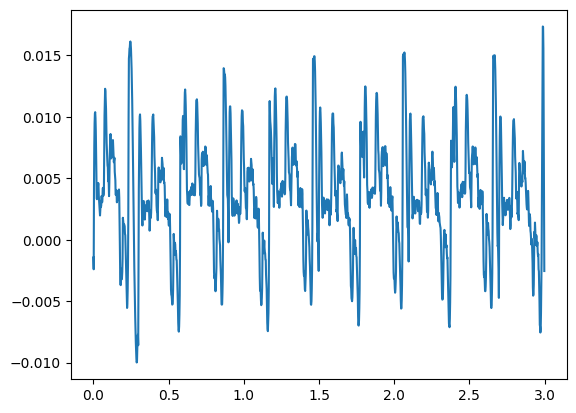

In [63]:
plt.figure()

print(bsps_all_models[0].shape)
t = np.arange(len(bsps_all_models[0][0,:]))/500
plt.plot(t,bsps_all_models[0][0,:])



In [68]:
#nos quedamos con 64 nodos para los bsps como chaqueta
bsps_64_all_models = []
for i in range(len(bsps_all_models)):

    bsps_64 = bsps_all_models[i][A[1].ravel(),:]
    print(bsps_64.shape)
    bsps_64_all_models.append(bsps_64)


(64, 1500)
(64, 2499)
(64, 1301)
(64, 1500)
(64, 4000)
(64, 4000)
(64, 2000)
(64, 2000)
(64, 2001)
(64, 2499)
(64, 2499)
(64, 4501)


In [73]:
print(len(bsps_64_all_models))

12
